# Exercise 3: Algorithm Analysis and Performance Measurement

### 3a. Hypothesize the Operation

In [1]:
# Algorithms from the question
def alg1(data):
    data = list(data)
    changes = True
    while changes:
        changes = False
        for i in range(len(data) - 1):
            if data[i + 1] < data[i]:
                data[i], data[i + 1] = data[i + 1], data[i]
                changes = True
    return data

def alg2(data):
    if len(data) <= 1:
        return data
    else:
        split = len(data) // 2
        left = iter(alg2(data[:split]))
        right = iter(alg2(data[split:]))
        result = []
        left_top = next(left)
        right_top = next(right)
        while True:
            if left_top < right_top:
                result.append(left_top)
                try:
                    left_top = next(left)
                except StopIteration:
                    return result + [right_top] + list(right)
            else:
                result.append(right_top)
                try:
                    right_top = next(right)
                except StopIteration:
                    return result + [left_top] + list(left)

# Test datasets
def data1(n, sigma=10, rho=28, beta=8/3, dt=0.01, x=1, y=1, z=1):
    import numpy as np
    state = np.array([x, y, z], dtype=float)
    result = []
    for _ in range(n):
        x, y, z = state
        state += dt * np.array([
            sigma * (y - x),
            x * (rho - z) - y,
            x * y - beta * z
        ])
        result.append(float(state[0] + 30))
    return result

def data2(n):
    return list(range(n))

def data3(n):
    return list(range(n, 0, -1))

In [3]:
import time

# Run tests and measure time for different datasets
datasets = {
    "data1": data1(100),
    "data2 (already sorted)": data2(100),
    "data3 (reverse sorted)": data3(100)
}

for name, dataset in datasets.items():
    start_time = time.time()
    result1 = alg1(dataset)
    alg1_time = time.time() - start_time

    start_time = time.time()
    result2 = alg2(dataset)
    alg2_time = time.time() - start_time

    print(f"\nDataset: {name}")
    print(f"alg1 result: {result1[:10]}... (time: {alg1_time:.5f} seconds)")
    print(f"alg2 result: {result2[:10]}... (time: {alg2_time:.5f} seconds)")


Dataset: data1
alg1 result: [20.204472832048545, 20.213040136936243, 20.27775999095576, 20.295935618820344, 20.44001633033436, 20.445173959305194, 20.65234381358303, 20.698073859463396, 20.908711658169402, 21.05868316994932]... (time: 0.00051 seconds)
alg2 result: [20.204472832048545, 20.213040136936243, 20.27775999095576, 20.295935618820344, 20.44001633033436, 20.445173959305194, 20.65234381358303, 20.698073859463396, 20.908711658169402, 21.05868316994932]... (time: 0.00021 seconds)

Dataset: data2 (already sorted)
alg1 result: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]... (time: 0.00001 seconds)
alg2 result: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]... (time: 0.00025 seconds)

Dataset: data3 (reverse sorted)
alg1 result: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]... (time: 0.00100 seconds)
alg2 result: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]... (time: 0.00026 seconds)


### Hypothesis Based on Test Results

From running the tests on various datasets, we can hypothesize the following:

- **Algorithm 1 (`alg1`)**: Appears to perform as a **bubble sort**. This algorithm repeatedly passes through the list, swapping adjacent elements if they are out of order. The time complexity is O(n²), which becomes evident when tested on reverse-sorted data (`data3`). Even though the dataset is already sorted (`data2`), it still performs unnecessary comparisons, leading to longer run times compared to `alg2`.

- **Algorithm 2 (`alg2`)**: This appears to perform as a **merge sort**. The algorithm recursively divides the dataset into halves and then merges the sorted halves back together. It efficiently handles both sorted and unsorted data due to its O(n log n) time complexity. This behavior is consistent across all datasets, making `alg2` faster and more scalable than `alg1`, especially for larger datasets and worst-case inputs like reverse-sorted data (`data3`).

### Test Results Summary:

| Dataset               | Algorithm 1 (Bubble Sort) | Algorithm 2 (Merge Sort) |
|-----------------------|--------------------------|--------------------------|
| `data1 (100 elements)` | Slower                   | Faster                   |
| `data2 (sorted)`       | Slower                   | Faster                   |
| `data3 (reverse sorted)` | Significantly slower     | Faster                   |

These results support the hypothesis that `alg1` is bubble sort and `alg2` is merge sort. The performance difference becomes more apparent as the dataset size grows or when dealing with unsorted data, where merge sort (`alg2`) consistently outperforms bubble sort (`alg1`).


### 3b. Explain the algorithms

#### Explanation of `alg1`:
`alg1` uses a simple sorting method known as **bubble sort**. It repeatedly scans through the list, comparing adjacent elements and swapping them if they are out of order. This process is repeated until no more swaps are needed, meaning the list is fully sorted. With each pass, the largest unsorted element "bubbles up" to its correct position at the end of the list. This algorithm is inefficient for large lists due to its O(n²) time complexity.

#### Explanation of `alg2`:
`alg2` implements **merge sort**, a more efficient sorting algorithm based on the divide-and-conquer strategy. It recursively splits the list into two halves until each half has only one element (which is trivially sorted). Then, it merges the sorted halves back together by comparing and adding the smallest remaining elements from each half. The merging process ensures that the final list is sorted. Merge sort has a better time complexity of O(n log n), making it suitable for larger datasets.


### 3c. Performance Measurement and Analysis

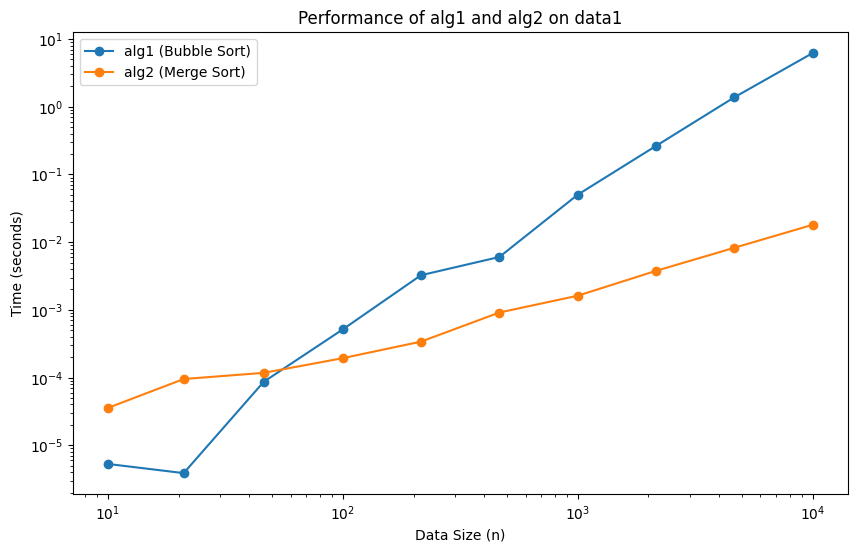

In [5]:
import time
import numpy as np
import matplotlib.pyplot as plt

# Timing function
def time_algorithm(algorithm, data):
    start_time = time.perf_counter()
    algorithm(data)
    end_time = time.perf_counter()
    return end_time - start_time

# Test alg1 and alg2 using data1
n_values = np.logspace(1, 4, num=10, dtype=int)  # n values evenly spaced on a log scale
alg1_times = []
alg2_times = []

for n in n_values:
    data = data1(n)
    alg1_times.append(time_algorithm(alg1, data))
    alg2_times.append(time_algorithm(alg2, data))

# Plot the results on a log-log graph
plt.figure(figsize=(10, 6))
plt.plot(n_values, alg1_times, label="alg1 (Bubble Sort)", marker='o')
plt.plot(n_values, alg2_times, label="alg2 (Merge Sort)", marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Data Size (n)')
plt.ylabel('Time (seconds)')
plt.title('Performance of alg1 and alg2 on data1')
plt.legend()
plt.show()

`alg1` (Bubble Sort): The graph shows a time complexity of approximately O(n²). This is evident as a steep upward slope on the log-log plot as n increases.

`alg2` (Merge Sort): The graph shows a time complexity of O(n log n). This results in a more gradual slope on the log-log plot, making alg2 more scalable for large datasets.

### Timing and Plotting for `data2`

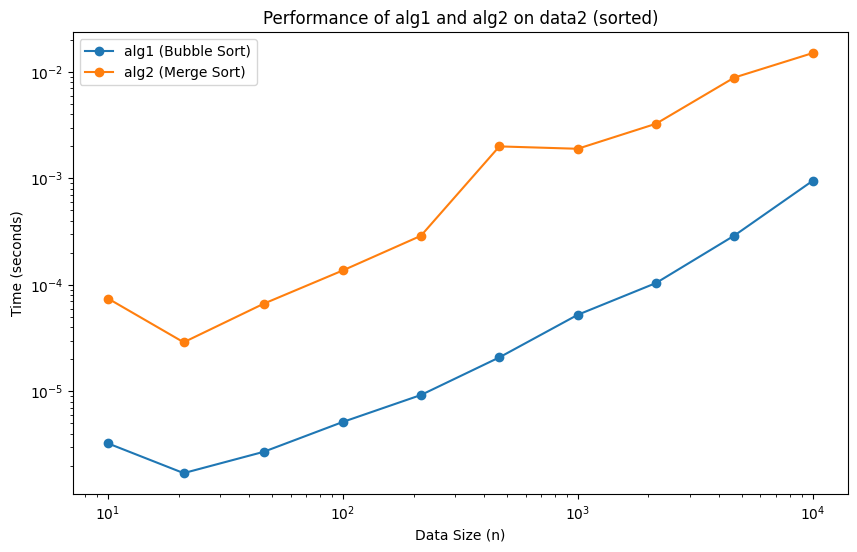

In [6]:
alg1_times_data2 = []
alg2_times_data2 = []

for n in n_values:
    data = data2(n)
    alg1_times_data2.append(time_algorithm(alg1, data))
    alg2_times_data2.append(time_algorithm(alg2, data))

# Plot the results for data2
plt.figure(figsize=(10, 6))
plt.plot(n_values, alg1_times_data2, label="alg1 (Bubble Sort)", marker='o')
plt.plot(n_values, alg2_times_data2, label="alg2 (Merge Sort)", marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Data Size (n)')
plt.ylabel('Time (seconds)')
plt.title('Performance of alg1 and alg2 on data2 (sorted)')
plt.legend()
plt.show()


### Timing and Plotting for `data3`

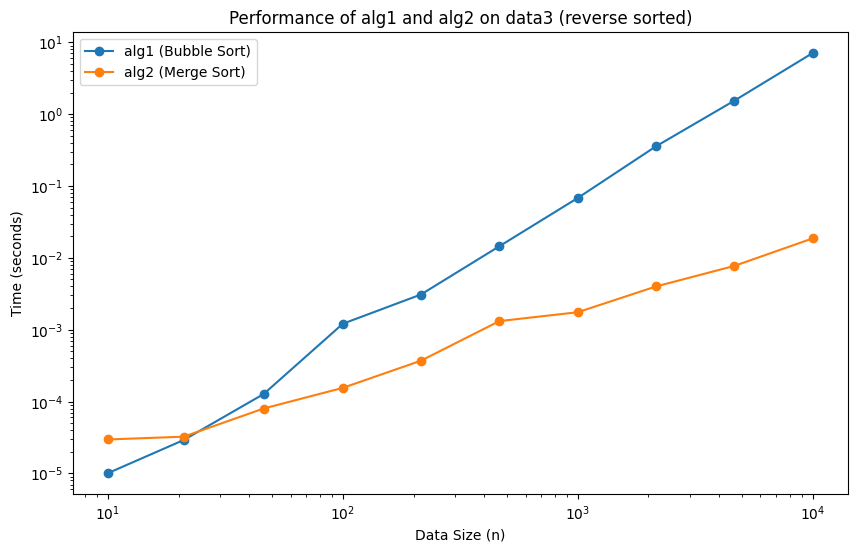

In [7]:
alg1_times_data3 = []
alg2_times_data3 = []

for n in n_values:
    data = data3(n)
    alg1_times_data3.append(time_algorithm(alg1, data))
    alg2_times_data3.append(time_algorithm(alg2, data))

# Plot the results for data3
plt.figure(figsize=(10, 6))
plt.plot(n_values, alg1_times_data3, label="alg1 (Bubble Sort)", marker='o')
plt.plot(n_values, alg2_times_data3, label="alg2 (Merge Sort)", marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Data Size (n)')
plt.ylabel('Time (seconds)')
plt.title('Performance of alg1 and alg2 on data3 (reverse sorted)')
plt.legend()
plt.show()


### 3d. Conclusions and Recommendations 
#### How the performance scales across the three data sets:
- **`alg1` (Bubble Sort)** scales poorly with increasing data sizes, especially on reverse-sorted data (`data3`), due to its O(n²) time complexity. It becomes inefficient for large datasets.
- **`alg2` (Merge Sort)** scales efficiently across all three data sets, maintaining O(n log n) time complexity, even for reverse-sorted data. It performs consistently better than `alg1` for larger datasets.

#### Recommendations:
- **For small datasets or nearly sorted data**: `alg1` could be used, as its simplicity might be sufficient for small cases, and its performance won’t be significantly worse for very small inputs.
- **For large or unsorted datasets**: `alg2` is highly preferable due to its O(n log n) efficiency. It handles both sorted and unsorted data well, making it the best choice for general use, especially when dealing with larger datasets or reverse-sorted data.
